In [1]:
!pip install nibabel numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 6.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm

# Paths
DATA_DIR = "/home/jovyan/fedgin/data"
OUTPUT_DIR = "/home/jovyan/fedgin/processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Organs to extract
ORGANS = [
    "liver",
    "spleen",
    "pancreas",
    "kidney_left",
    "kidney_right",
    "gallbladder"
]

def load_nifti(path):
    return nib.load(path).get_fdata()

def process_patient(patient_path, patient_id):
    ct_path = os.path.join(patient_path, "ct.nii.gz")
    
    if not os.path.exists(ct_path):
        return
    
    ct = load_nifti(ct_path)

    masks = []
    
    for organ in ORGANS:
        organ_path = os.path.join(patient_path, "segmentations", f"{organ}.nii.gz")
        
        if os.path.exists(organ_path):
            mask = load_nifti(organ_path)
        else:
            mask = np.zeros_like(ct)
        
        masks.append(mask)

    # Combine kidneys (left + right)
    kidney = masks[3] + masks[4]
    masks[3] = kidney
    masks.pop(4)

    # Stack masks
    mask_stack = np.stack(masks, axis=0)

    # Normalize CT
    ct = (ct - np.mean(ct)) / (np.std(ct) + 1e-8)

    # Save
    np.save(os.path.join(OUTPUT_DIR, f"{patient_id}_ct.npy"), ct)
    np.save(os.path.join(OUTPUT_DIR, f"{patient_id}_mask.npy"), mask_stack)


# Process all patients
patients = sorted(os.listdir(DATA_DIR))

for p in tqdm(patients):
    patient_path = os.path.join(DATA_DIR, p)
    
    if os.path.isdir(patient_path):
        process_patient(patient_path, p)

print("Processing done!")

100%|██████████| 104/104 [19:32<00:00, 11.28s/it]

Processing done!


In [3]:
import os

processed_path = "/home/jovyan/fedgin/processed"
files = os.listdir(processed_path)

print("Number of files:", len(files))
print(files[:10])  # show first few

Number of files: 204
['s0522_mask.npy', 's0763_ct.npy', 's0250_mask.npy', 's0058_mask.npy', 's0223_mask.npy', 's1082_mask.npy', 's1372_mask.npy', 's1123_mask.npy', 's0703_mask.npy', 's0454_mask.npy']


In [7]:
import numpy as np

ct = np.load("/home/jovyan/fedgin/processed/s0522_ct.npy")
mask = np.load("/home/jovyan/fedgin/processed/s0522_mask.npy")

In [8]:
print("Mask shape:", mask.shape)
print("Number of organs:", mask.shape[0])

Mask shape: (5, 249, 249, 199)
Number of organs: 5


In [9]:
print("CT shape:", ct.shape)
print("Mask values:", np.unique(mask))

CT shape: (249, 249, 199)
Mask values: [0. 1.]


In [11]:
import os

SLICE_DIR = "/home/jovyan/fedgin/slices"
os.makedirs(SLICE_DIR, exist_ok=True)

In [12]:
import numpy as np
import os
from tqdm import tqdm

PROCESSED_DIR = "/home/jovyan/fedgin/processed"
SLICE_DIR = "/home/jovyan/fedgin/slices"

os.makedirs(SLICE_DIR, exist_ok=True)

files = sorted(os.listdir(PROCESSED_DIR))

# Get unique patient IDs
patients = sorted(set(f.split("_")[0] for f in files))

slice_count = 0

for p in tqdm(patients):
    ct_path = os.path.join(PROCESSED_DIR, f"{p}_ct.npy")
    mask_path = os.path.join(PROCESSED_DIR, f"{p}_mask.npy")
    
    if not os.path.exists(ct_path):
        continue
    
    ct = np.load(ct_path)
    mask = np.load(mask_path)
    
    depth = ct.shape[2]
    
    for i in range(depth):
        ct_slice = ct[:, :, i]
        mask_slice = mask[:, :, :, i]
        
        # Skip empty slices (no organs)
        if np.sum(mask_slice) == 0:
            continue
        
        np.save(os.path.join(SLICE_DIR, f"{p}_{i}_ct.npy"), ct_slice)
        np.save(os.path.join(SLICE_DIR, f"{p}_{i}_mask.npy"), mask_slice)
        
        slice_count += 1

print("Total slices saved:", slice_count)

100%|██████████| 102/102 [06:21<00:00,  3.74s/it]

Total slices saved: 10832


In [13]:
import os

slice_files = os.listdir("/home/jovyan/fedgin/slices")
print("Total slice files:", len(slice_files))
print(slice_files[:10])

Total slice files: 21664
['s0965_184_mask.npy', 's0481_25_ct.npy', 's1388_199_mask.npy', 's1371_402_mask.npy', 's1127_202_mask.npy', 's1364_179_mask.npy', 's1371_288_mask.npy', 's0720_281_mask.npy', 's1336_219_mask.npy', 's1127_179_mask.npy']


In [16]:
import numpy as np

ct = np.load("/home/jovyan/fedgin/slices/" + files[0])
mask = np.load("/home/jovyan/fedgin/slices/" + files[1])

print("CT shape:", ct.shape)
print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

CT shape: (5, 215, 215)
Mask shape: (207, 207)
Mask values: [-1.39195557 -1.38186363 -1.35158779 ...  6.41315514  6.79463068
  6.81885135]


In [22]:
import os

slice_path = "/home/jovyan/fedgin/slices"
files = os.listdir(slice_path)

# pick correct files explicitly
ct_file = [f for f in files if "_ct.npy" in f][0]
mask_file = [f for f in files if "_mask.npy" in f][0]

print(ct_file, mask_file)

s0481_25_ct.npy s0965_184_mask.npy


In [23]:
import numpy as np

ct = np.load(os.path.join(slice_path, ct_file))
mask = np.load(os.path.join(slice_path, mask_file))

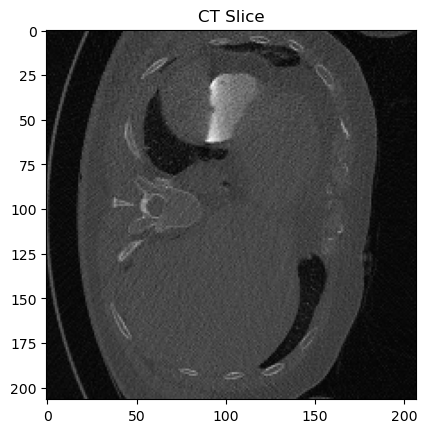

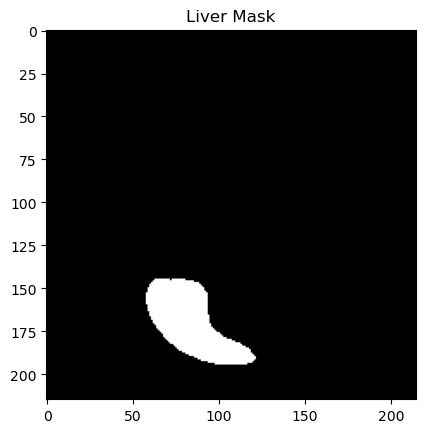

In [24]:
import matplotlib.pyplot as plt

# CT image
plt.imshow(ct, cmap='gray')
plt.title("CT Slice")
plt.show()

# Mask (choose one organ)
plt.imshow(mask[0], cmap='gray')
plt.title("Liver Mask")
plt.show()

In [25]:
print("CT shape:", ct.shape)
print("Mask shape:", mask.shape)

CT shape: (207, 207)
Mask shape: (5, 215, 215)
